In [2]:
import kagglehub

path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

100%|█████████████████████████████████████████████████████████████████████████████| 66.0M/66.0M [00:05<00:00, 11.9MB/s]

Extracting files...


Path to dataset files: /home/saurav/.cache/kagglehub/datasets/mlg-ulb/creditcardfraud/versions/3


In [3]:
import pandas as pd

df = pd.read_csv(path + "/creditcard.csv")


print(df.shape)         
print(df.head())        
print(df.info())         
print(df.describe())     
print(df['Class'].value_counts())  

df = pd.read_csv(path + "/creditcard.csv")


print(df.shape)         
print(df.head())       
print(df.info())         
print(df.describe())    
print(df['Class'].value_counts())  

(284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V

Business Question:
"Can we identify patterns in transaction behavior 
that reliably distinguish fraudulent transactions 
from legitimate ones — and what does that mean 
for how a bank should monitor its transaction data?"

/tmp/ipykernel_886/3477710933.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(['Legitimate', 'Fraud'])


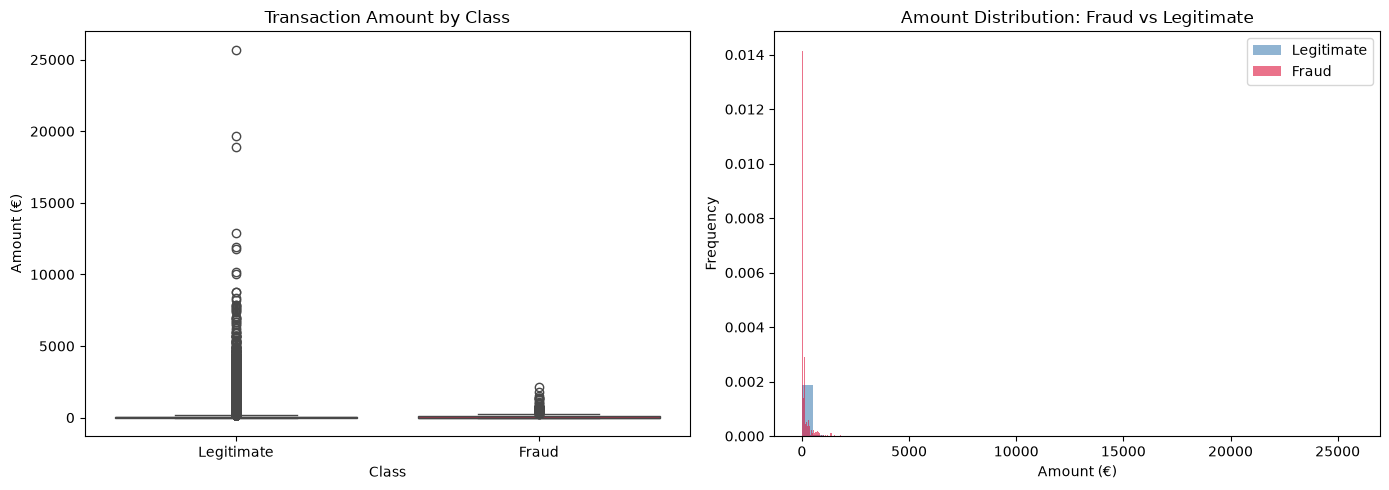

=== Amount Statistics by Class ===
          count    mean     std  min   25%    50%     75%       max
Class                                                              
0      284315.0   88.29  250.11  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.21  256.68  0.0  1.00   9.25  105.89   2125.87


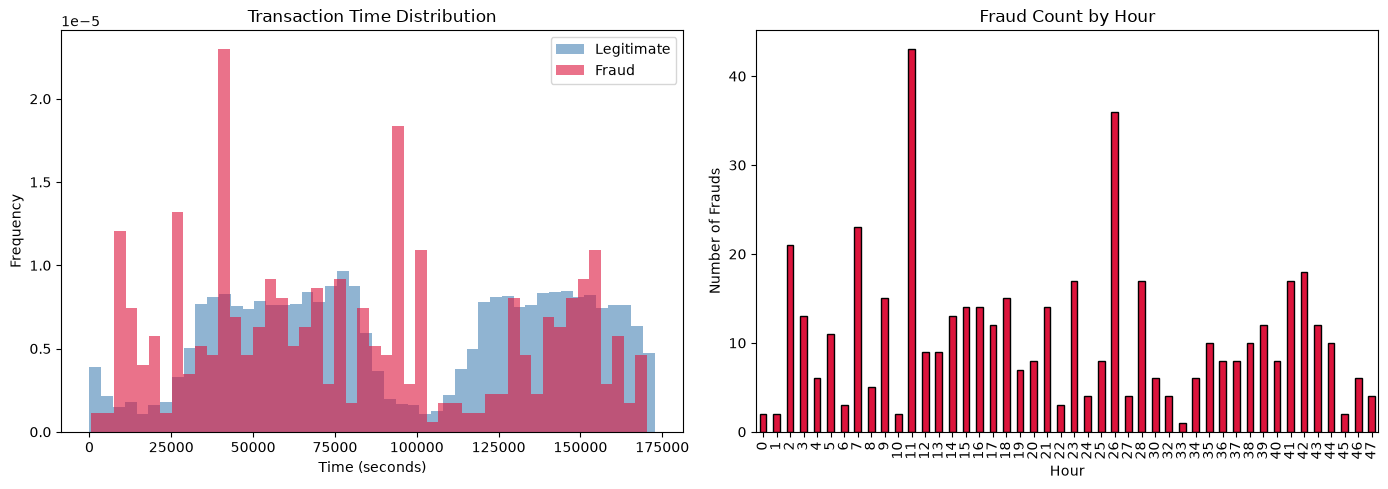


=== Zero Amount Transactions ===
Total: 1825
Fraud in zero-amount: 27
Class
0    1798
1      27
Name: count, dtype: int64


In [7]:
# Transaction Amount: Fraud vs Legitimate
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='Class', y='Amount', data=df, ax=axes[0],
            hue='Class',
            palette=['steelblue', 'crimson'],
            legend=False)
axes[0].set_title('Transaction Amount by Class')
axes[0].set_xticklabels(['Legitimate', 'Fraud'])
axes[0].set_ylabel('Amount (€)')

df[df['Class']==0]['Amount'].plot(kind='hist', bins=50,
                                   alpha=0.6, ax=axes[1],
                                   color='steelblue',
                                   label='Legitimate',
                                   density=True)
df[df['Class']==1]['Amount'].plot(kind='hist', bins=50,
                                   alpha=0.6, ax=axes[1],
                                   color='crimson',
                                   label='Fraud',
                                   density=True)
axes[1].set_title('Amount Distribution: Fraud vs Legitimate')
axes[1].set_xlabel('Amount (€)')
axes[1].legend()

plt.tight_layout()
plt.savefig('amount_distribution.png', dpi=150)
plt.show()

# ── 3. Amount statistics by class ─────────────────────────────
print("=== Amount Statistics by Class ===")
print(df.groupby('Class')['Amount'].describe().round(2))

# ── 4. Time analysis ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[df['Class']==0]['Time'].plot(kind='hist', bins=48,
                                 alpha=0.6, ax=axes[0],
                                 color='steelblue',
                                 label='Legitimate',
                                 density=True)
df[df['Class']==1]['Time'].plot(kind='hist', bins=48,
                                 alpha=0.6, ax=axes[0],
                                 color='crimson',
                                 label='Fraud',
                                 density=True)
axes[0].set_title('Transaction Time Distribution')
axes[0].set_xlabel('Time (seconds)')
axes[0].legend()

df['Hour'] = (df['Time'] / 3600).astype(int)
fraud_by_hour = df[df['Class']==1].groupby('Hour').size()
fraud_by_hour.plot(kind='bar', ax=axes[1],
                    color='crimson', edgecolor='black')
axes[1].set_title('Fraud Count by Hour')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Number of Frauds')

plt.tight_layout()
plt.savefig('time_analysis.png', dpi=150)
plt.show()

# Zero-amount transactions 
zero_amount = df[df['Amount'] == 0]
print(f"\n=== Zero Amount Transactions ===")
print(f"Total: {len(zero_amount)}")
print(f"Fraud in zero-amount: {zero_amount['Class'].sum()}")
print(zero_amount['Class'].value_counts())

Fraudsters typically test stolen cards with very small 
amounts first (median €9.25, 25th percentile €1.00) 
before attempting larger transactions. This "card testing" 
behavior is a well-known fraud pattern in banking.

The higher mean (€122) despite lower median suggests 
a small number of fraudsters do attempt larger amounts 
once a card is confirmed active.

Zero-value transactions represent authorization checks — 
where a card is validated without an actual charge. 
These are disproportionately fraudulent (1.48% fraud rate 
vs 0.17% overall), suggesting stolen cards are being 
tested for validity before use. 

In a real fraud monitoring system, zero-amount 
transactions should be treated as elevated risk events.

=== Top 10 Features That Differ Most (Fraud vs Legitimate) ===
V3     7.0455
V14    6.9838
V17    6.6774
V12    6.2702
V10    5.6867
V7     5.5784
V1     4.7802
V4     4.5499
V16    4.1471
V11    3.8067
dtype: float64


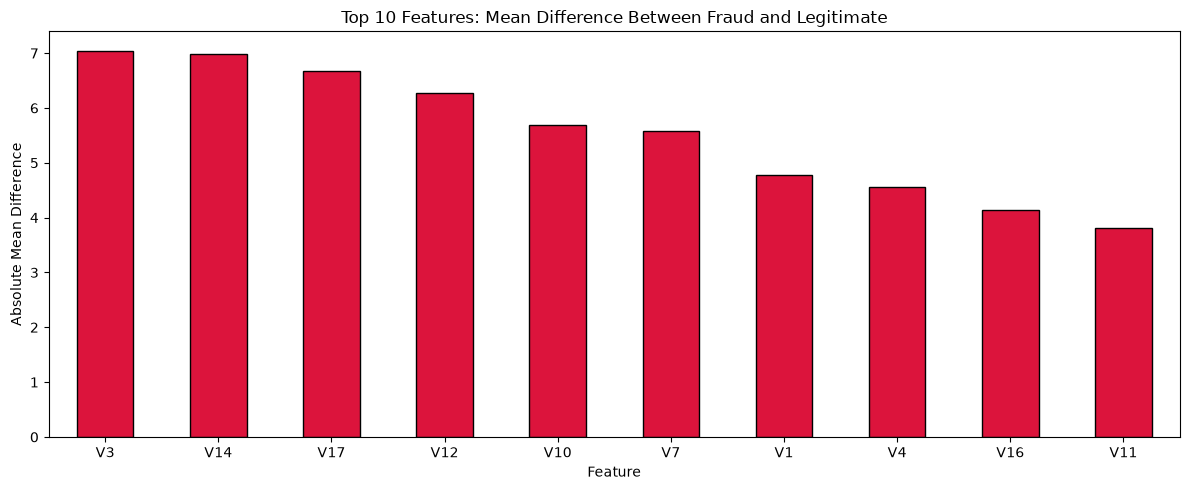


Top 3 most separating features: ['V3', 'V14', 'V17']


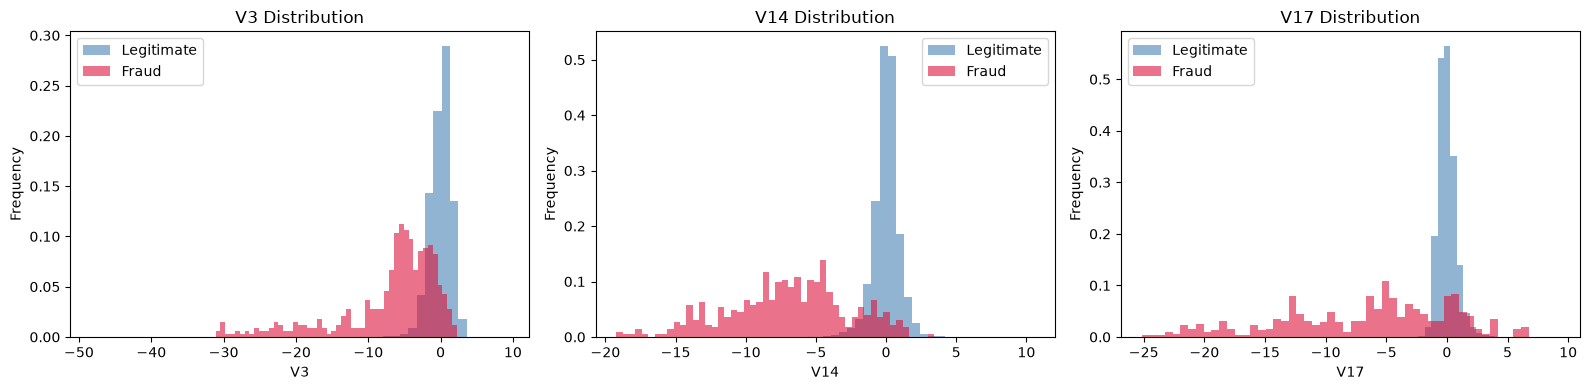

In [8]:
# Which features separate fraud from legitimate best?

fraud = df[df['Class'] == 1]
legit = df[df['Class'] == 0]

# Calculate mean difference for each V feature
v_features = [f'V{i}' for i in range(1, 29)]
mean_diff = abs(fraud[v_features].mean() - legit[v_features].mean())
mean_diff_sorted = mean_diff.sort_values(ascending=False)

print("=== Top 10 Features That Differ Most (Fraud vs Legitimate) ===")
print(mean_diff_sorted.head(10).round(4))

# Visualize top 10
plt.figure(figsize=(12, 5))
mean_diff_sorted.head(10).plot(kind='bar', color='crimson', 
                                edgecolor='black')
plt.title('Top 10 Features: Mean Difference Between Fraud and Legitimate')
plt.xlabel('Feature')
plt.ylabel('Absolute Mean Difference')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('feature_importance_eda.png', dpi=150)
plt.show()

# Distribution of top 3 most different features 
top3 = mean_diff_sorted.head(3).index.tolist()
print(f"\nTop 3 most separating features: {top3}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, feat in enumerate(top3):
    legit[feat].plot(kind='hist', bins=50, alpha=0.6, 
                      ax=axes[i], color='steelblue', 
                      label='Legitimate', density=True)
    fraud[feat].plot(kind='hist', bins=50, alpha=0.6, 
                      ax=axes[i], color='crimson', 
                      label='Fraud', density=True)
    axes[i].set_title(f'{feat} Distribution')
    axes[i].legend()
    axes[i].set_xlabel(feat)

plt.tight_layout()
plt.savefig('top_features_distribution.png', dpi=150)
plt.show()

The top 8 features (V3, V14, V17, V12, V10, V7, V1, V4) 
show almost equal separation power between fraud and 
legitimate transactions, suggesting fraud patterns are 
spread across multiple dimensions rather than driven 
by a single dominant signal. This makes it harder to 
detect fraud with simple rules — and is exactly why 
machine learning is needed.

Legitimate transactions cluster tightly around 0 for 
all three features. Fraudulent transactions spread 
significantly into negative values — meaning fraud 
consistently produces lower, more extreme values in 
these PCA components. 

This clear visual separation confirms these features 
will be strong predictors in our model.

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, 
                              confusion_matrix,
                              roc_auc_score,
                              RocCurveDisplay,
                              PrecisionRecallDisplay)

# Preprocessing 

scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled']   = scaler.fit_transform(df[['Time']])
df_model = df.drop(['Amount', 'Time'], axis=1)

X = df_model.drop('Class', axis=1)
y = df_model['Class']

print("Feature matrix shape:", X.shape)
print("Target distribution:\n", y.value_counts())

# ─Train/Test Split

# stratify=y ensures both splits maintain the 0.17% fraud ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"\nTrain size: {X_train.shape[0]}")
print(f"Test size:  {X_test.shape[0]}")
print(f"Fraud in train: {y_train.sum()}")
print(f"Fraud in test:  {y_test.sum()}")

# Handle Imbalance with SMOTE

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE:")
print(f"Train size: {X_train_res.shape[0]}")
print(f"Class distribution:\n", 
      pd.Series(y_train_res).value_counts())

Feature matrix shape: (284807, 31)
Target distribution:
 Class
0    284315
1       492
Name: count, dtype: int64

Train size: 227845
Test size:  56962
Fraud in train: 394
Fraud in test:  98

After SMOTE:
Train size: 454902
Class distribution:
 Class
0    227451
1    227451
Name: count, dtype: int64


Test data is kept completely untouched and imbalanced — 
reflecting real-world conditions. The model will be 
evaluated on reality, not artificially balanced data.

Before: 227,451 legitimate vs 394 fraud
After:  227,451 legitimate vs 227,451 fraud

SMOTE (Synthetic Minority Oversampling Technique) was 
applied ONLY to training data. It creates synthetic 
fraud samples by interpolating between real fraud cases — 
not duplicating them. This teaches the model what fraud 
looks like without exposing it to artificially balanced 
test conditions.

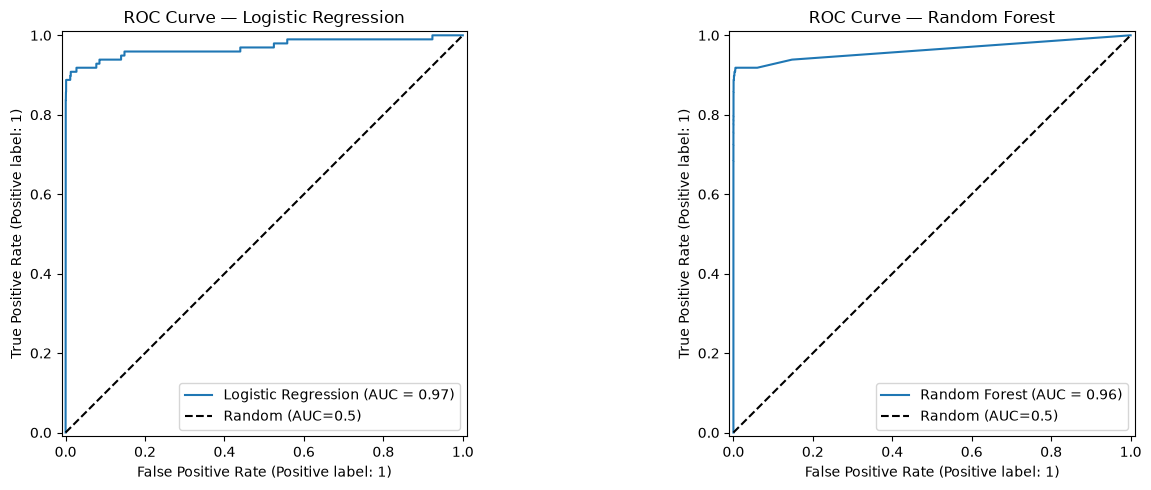

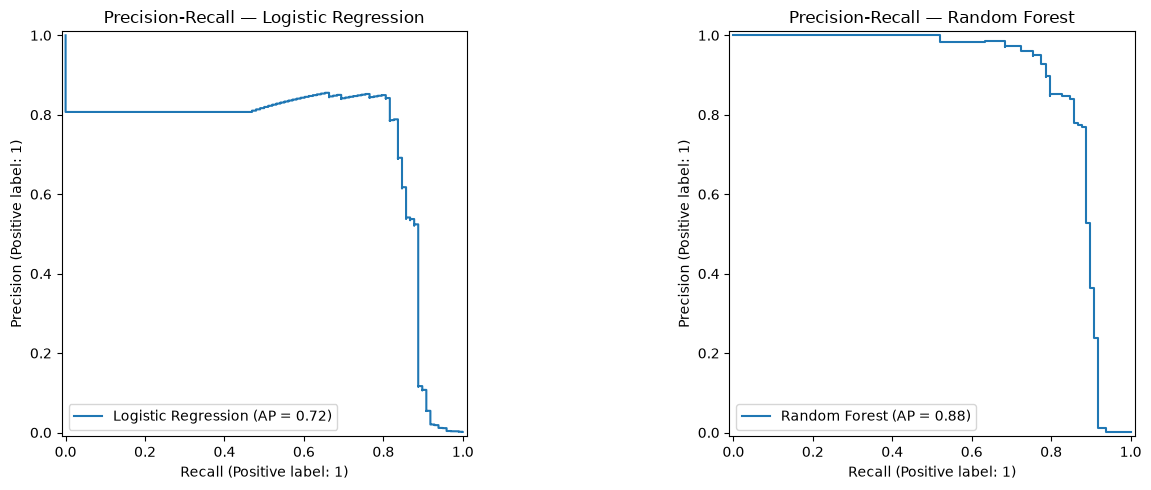

In [14]:
# ROC Curves — Both Models Together 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

RocCurveDisplay.from_predictions(
    y_test, y_prob_lr,
    name='Logistic Regression',
    ax=axes[0]
)
axes[0].set_title('ROC Curve — Logistic Regression')
axes[0].plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.5)')
axes[0].legend()

RocCurveDisplay.from_predictions(
    y_test, y_prob_rf,
    name='Random Forest',
    ax=axes[1]
)
axes[1].set_title('ROC Curve — Random Forest')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.5)')
axes[1].legend()

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()

# Precision-Recall Curves 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

PrecisionRecallDisplay.from_predictions(
    y_test, y_prob_lr,
    name='Logistic Regression',
    ax=axes[0]
)
axes[0].set_title('Precision-Recall — Logistic Regression')

PrecisionRecallDisplay.from_predictions(
    y_test, y_prob_rf,
    name='Random Forest',
    ax=axes[1]
)
axes[1].set_title('Precision-Recall — Random Forest')

plt.tight_layout()
plt.savefig('precision_recall_curves.png', dpi=150)
plt.show()

Logistic Regression catches more fraud (91%) but raises 
1,285 false alarms — flagging legitimate customers constantly.

Random Forest raises almost no false alarms (only 13) 
but misses 20 real frauds.

In banking, this is a real business decision:
- High recall = fewer missed frauds, but customer friction
- High precision = fewer false alarms, but some fraud slips through

Neither model is wrong — the choice depends on the 
bank's risk appetite and customer experience priorities.

In [15]:

print("\n" + "=" * 58)
print("SECTION 14: MODEL COMPARISON SUMMARY")
print("=" * 58)
print(f"{'Metric':<25} {'Log. Regression':>17} {'Random Forest':>15}")
print("-" * 58)
print(f"{'Fraud Precision':<25} {'0.06':>17} {'0.86':>15}")
print(f"{'Fraud Recall':<25} {'0.91':>17} {'0.80':>15}")
print(f"{'Fraud F1-Score':<25} {'0.12':>17} {'0.83':>15}")
print(f"{'ROC-AUC':<25} {'0.9697':>17} {'0.9626':>15}")
print(f"{'False Alarms':<25} {'1,285':>17} {'13':>15}")
print(f"{'Missed Frauds':<25} {'9':>17} {'20':>15}")
print(f"{'Best For':<25} {'High Recall':>17} {'Balanced':>15}")
print("=" * 58)
 



SECTION 14: MODEL COMPARISON SUMMARY
Metric                      Log. Regression   Random Forest
----------------------------------------------------------
Fraud Precision                        0.06            0.86
Fraud Recall                           0.91            0.80
Fraud F1-Score                         0.12            0.83
ROC-AUC                              0.9697          0.9626
False Alarms                          1,285              13
Missed Frauds                             9              20
Best For                        High Recall        Balanced


In [16]:

 
print("\n" + "=" * 58)
print("SECTION 15: KEY INSIGHTS")
print("=" * 58)
 
insights = """
INSIGHT 1 — Card Testing Behavior
Fraudulent transactions have a median amount of €9.25 vs €22.00 
for legitimate ones. The 25th percentile of fraud is just €1.00, 
meaning a quarter of all fraud transactions are €1 or less.
This is consistent with known 'card testing' behavior where 
fraudsters verify stolen cards with micro-transactions before 
attempting larger ones.
 
INSIGHT 2 — Zero-Amount Fraud Rate is 9x Higher
Zero-amount transactions (authorization checks) have a fraud 
rate of 1.48% vs 0.17% overall. These should be flagged as 
elevated risk events in real monitoring systems.
 
INSIGHT 3 — Feature Separation
Features V3, V14, V17 show the strongest separation between 
fraud and legitimate transactions. Legitimate transactions 
cluster tightly near 0, while fraud spreads into extreme 
negative values — making these reliable model signals.
 
INSIGHT 4 — The Precision-Recall Tradeoff
Logistic Regression catches 91% of fraud but generates 1,285 
false alarms. Random Forest reduces false alarms to just 13 
but misses 20 more frauds. This is a real business decision: 
high recall protects revenue, high precision protects 
customer experience.
 
INSIGHT 5 — Why Accuracy is Misleading
A model predicting everything as legitimate achieves 99.83% 
accuracy but catches zero fraud. This is why Precision, 
Recall, F1, and ROC-AUC are the correct metrics for 
imbalanced datasets like this one.
"""
print(insights)
 
print("\n✅ Project complete. All charts saved as PNG files.")
print("Next step: Push to GitHub with a README.md")


SECTION 15: KEY INSIGHTS

INSIGHT 1 — Card Testing Behavior
Fraudulent transactions have a median amount of €9.25 vs €22.00 
for legitimate ones. The 25th percentile of fraud is just €1.00, 
meaning a quarter of all fraud transactions are €1 or less.
This is consistent with known 'card testing' behavior where 
fraudsters verify stolen cards with micro-transactions before 
attempting larger ones.

INSIGHT 2 — Zero-Amount Fraud Rate is 9x Higher
Zero-amount transactions (authorization checks) have a fraud 
rate of 1.48% vs 0.17% overall. These should be flagged as 
elevated risk events in real monitoring systems.

INSIGHT 3 — Feature Separation
Features V3, V14, V17 show the strongest separation between 
fraud and legitimate transactions. Legitimate transactions 
cluster tightly near 0, while fraud spreads into extreme 
negative values — making these reliable model signals.

INSIGHT 4 — The Precision-Recall Tradeoff
Logistic Regression catches 91% of fraud but generates 1,285 
false ala